## Compare Aurora vs TiDB Retrieval Performance

This section demonstrates the performance difference between:
- **Aurora RDS MySQL** (`ai_state_management`): No partitioning
- **TiDB** (`ai_state_management`): Partitioned by session_id

**Schema:** Both databases have identical schema. Messages table only has session_id as foreign key.

**Partitioning Strategy:**
- Aurora: no partitioning - messages scattered across storage
- TiDB: partitioned by session_id - all messages for a session are in ONE partition

**Query:** Both use `WHERE session_id = ?`

This proves that partitioning by session_id improves session retrieval performance.

In [3]:
# Import required libraries and load environment variables
import pymysql
import time
import pandas as pd
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Aurora RDS MySQL Configuration
AURORA_HOST = os.getenv('AURORA_HOST')
AURORA_PORT = int(os.getenv('AURORA_PORT', 3306))
AURORA_USER = os.getenv('AURORA_USER', 'admin')
AURORA_PASSWORD = os.getenv('AURORA_PASSWORD')
AURORA_DATABASE = os.getenv('AURORA_DATABASE', 'ai_state_management')

# TiDB Configuration
TIDB_HOST = os.getenv('TIDB_HOST', '127.0.0.1')
TIDB_PORT = int(os.getenv('TIDB_PORT', 3306))
TIDB_USER = os.getenv('TIDB_USER', 'root')
TIDB_PASSWORD = os.getenv('TIDB_PASSWORD', '')
TIDB_DATABASE = os.getenv('TIDB_DATABASE', 'ai_state_management')

print("Configuration loaded from .env:")
print(f"  Aurora: {AURORA_HOST}:{AURORA_PORT} - {AURORA_DATABASE}")
print(f"  TiDB:   {TIDB_HOST}:{TIDB_PORT} - {TIDB_DATABASE}")

Configuration loaded from .env:
  Aurora: ai-state-management.c6loqao2038b.us-east-1.rds.amazonaws.com:3306 - ai_state_management
  TiDB:   127.0.0.1:3306 - ai_state_management


In [4]:
# Connect to both databases
aurora_conn = pymysql.connect(
    host=AURORA_HOST,
    port=AURORA_PORT,
    user=AURORA_USER,
    password=AURORA_PASSWORD,
    database=AURORA_DATABASE,
    cursorclass=pymysql.cursors.DictCursor
)

tidb_conn = pymysql.connect(
    host=TIDB_HOST,
    port=TIDB_PORT,
    user=TIDB_USER,
    password=TIDB_PASSWORD,
    database=TIDB_DATABASE,
    cursorclass=pymysql.cursors.DictCursor
)

print("Connected to both databases:")
print(f"  ✓ Aurora RDS MySQL ({AURORA_DATABASE})")
print(f"  ✓ TiDB ({TIDB_DATABASE} - partitioned)")

Connected to both databases:
  ✓ Aurora RDS MySQL (ai_state_management)
  ✓ TiDB (ai_state_management - partitioned)


In [5]:
# Find top sessions with many messages (from Aurora)
with aurora_conn.cursor() as cursor:
    cursor.execute("""
        SELECT s.session_id, s.user_id, s.bot_id, 
               u.username, b.bot_name,
               s.message_count
        FROM sessions s
        JOIN users u ON s.user_id = u.user_id
        JOIN bots b ON s.bot_id = b.bot_id
        WHERE s.message_count > 0
        ORDER BY s.message_count DESC
        LIMIT 10
    """)
    top_sessions = cursor.fetchall()

print(f"Found {len(top_sessions)} sessions with messages:\n")
for idx, session in enumerate(top_sessions, 1):
    print(f"{idx:2d}. {session['username']:20s} <-> {session['bot_name']:20s}: {session['message_count']:3d} messages")

Found 10 sessions with messages:

 1. charlie.martinez193  <-> Travel Assistant    :  50 messages
 2. bob.wilson275        <-> Learning Coach      :  50 messages
 3. jack.davis706        <-> Sales Agent         :  50 messages
 4. iris.martin933       <-> Learning Coach      :  50 messages
 5. liam.martin337       <-> Learning Coach      :  50 messages
 6. ruby.davis603        <-> Financial Advisor   :  50 messages
 7. quinn.gonzalez868    <-> Financial Advisor   :  50 messages
 8. iris.wilson917       <-> Language Tutor      :  50 messages
 9. kate.johnson202      <-> General Assistant   :  49 messages
10. kate.lopez419        <-> Sales Agent         :  49 messages


In [6]:
def measure_retrieval_time(conn, session_id):
    """
    Measure message retrieval time for a session.
    Both databases use the same query: WHERE session_id = ?
    
    The performance difference comes from partitioning:
    - Aurora: no partitioning, must scan entire table
    - TiDB: partitioned by session_id, scans only 1 of 8 partitions
    """
    query = """
        SELECT message_id, role, content, created_at, tokens_used
        FROM messages
        WHERE session_id = %s
        ORDER BY created_at ASC
    """
    
    start_time = time.time()
    with conn.cursor() as cursor:
        cursor.execute(query, (session_id,))
        messages = cursor.fetchall()
    elapsed_ms = (time.time() - start_time) * 1000
    
    return elapsed_ms, len(messages)

print("Retrieval measurement function defined")
print("  - Same query for both databases: WHERE session_id = ?")
print("  - TiDB partitioned by session_id for collocation")

Retrieval measurement function defined
  - Same query for both databases: WHERE session_id = ?
  - TiDB partitioned by session_id for collocation


In [7]:
# Measure retrieval time for each session on both databases
results = []

print("Measuring retrieval times for all sessions...\n")
print("=" * 80)

for idx, session in enumerate(top_sessions, 1):
    session_id = session['session_id']
    message_count = session['message_count']
    
    # Same query for both databases: WHERE session_id = ?
    time_aurora, count_aurora = measure_retrieval_time(aurora_conn, session_id)
    time_tidb, count_tidb = measure_retrieval_time(tidb_conn, session_id)
    
    # Record results
    results.append({
        'session_num': idx,
        'username': session['username'],
        'bot_name': session['bot_name'],
        'message_count': message_count,
        'aurora_ms': time_aurora,
        'tidb_ms': time_tidb,
        'speedup': time_aurora / time_tidb if time_tidb > 0 else 0
    })
    
    # Print progress
    speedup = time_aurora / time_tidb if time_tidb > 0 else 0
    print(f"Session {idx:2d}: {message_count:3d} msgs | "
          f"Aurora: {time_aurora:6.2f}ms | "
          f"TiDB: {time_tidb:6.2f}ms | "
          f"Speedup: {speedup:5.2f}x")

print("=" * 80)
print(f"\nMeasured {len(results)} sessions")

Measuring retrieval times for all sessions...

Session  1:  50 msgs | Aurora:  60.71ms | TiDB:   9.90ms | Speedup:  6.13x
Session  2:  50 msgs | Aurora:  54.01ms | TiDB:  18.60ms | Speedup:  2.90x
Session  3:  50 msgs | Aurora:  55.03ms | TiDB:   4.68ms | Speedup: 11.77x
Session  4:  50 msgs | Aurora:  63.53ms | TiDB:   2.60ms | Speedup: 24.45x
Session  5:  50 msgs | Aurora:  56.10ms | TiDB:   2.70ms | Speedup: 20.75x
Session  6:  50 msgs | Aurora:  54.12ms | TiDB:   2.51ms | Speedup: 21.57x
Session  7:  50 msgs | Aurora:  62.03ms | TiDB:   3.07ms | Speedup: 20.22x
Session  8:  50 msgs | Aurora:  53.73ms | TiDB:   2.84ms | Speedup: 18.90x
Session  9:  49 msgs | Aurora:  55.93ms | TiDB:   5.59ms | Speedup: 10.01x
Session 10:  49 msgs | Aurora:  53.89ms | TiDB:   6.74ms | Speedup:  7.99x

Measured 10 sessions


## Performance Analysis

Both databases have identical schema. The performance difference is entirely due to partitioning by session_id.

**Aurora RDS MySQL**: No partitioning - queries scan entire messages table
**TiDB**: Partitioned by session_id - queries scan only 1 of 8 partitions

This demonstrates the performance benefit of TiDB session-based data colocation.

In [8]:
# Create results dataframe
df_results = pd.DataFrame(results)

# Calculate statistics
avg_aurora = df_results['aurora_ms'].mean()
avg_tidb = df_results['tidb_ms'].mean()
avg_speedup = df_results['speedup'].mean()
median_speedup = df_results['speedup'].median()
max_speedup = df_results['speedup'].max()

print("=" * 80)
print("PERFORMANCE COMPARISON SUMMARY")
print("=" * 80)
print(f"\nTotal sessions tested: {len(results)}")
print(f"Total messages across all sessions: {df_results['message_count'].sum()}")
print(f"\nAverage retrieval times:")
print(f"  Aurora RDS MySQL (no partitioning):  {avg_aurora:6.2f} ms")
print(f"  TiDB (partitioned by session_id):    {avg_tidb:6.2f} ms")
print(f"\nSpeedup with TiDB partitioning:")
print(f"  Average speedup:  {avg_speedup:5.2f}x")
print(f"  Median speedup:   {median_speedup:5.2f}x")
print(f"  Maximum speedup:  {max_speedup:5.2f}x")
print(f"\nConclusion: TiDB is {avg_speedup:.2f}x faster on average")
print("=" * 80)

# Display detailed results
print("\nDetailed Results:")
print(df_results[['session_num', 'message_count', 'aurora_ms', 'tidb_ms', 'speedup']].to_string(index=False))

PERFORMANCE COMPARISON SUMMARY

Total sessions tested: 10
Total messages across all sessions: 498

Average retrieval times:
  Aurora RDS MySQL (no partitioning):   56.91 ms
  TiDB (partitioned by session_id):      5.92 ms

Speedup with TiDB partitioning:
  Average speedup:  14.47x
  Median speedup:   15.34x
  Maximum speedup:  24.45x

Conclusion: TiDB is 14.47x faster on average

Detailed Results:
 session_num  message_count  aurora_ms   tidb_ms   speedup
           1             50  60.712337  9.901047  6.131911
           2             50  54.005861 18.604994  2.902762
           3             50  55.027008  4.676104 11.767705
           4             50  63.529015  2.597809 24.454846
           5             50  56.101799  2.703190 20.753925
           6             50  54.121017  2.508879 21.571795
           7             50  62.026024  3.067255 20.221998
           8             50  53.729773  2.842188 18.904370
           9             49  55.927992  5.586147 10.011908
         

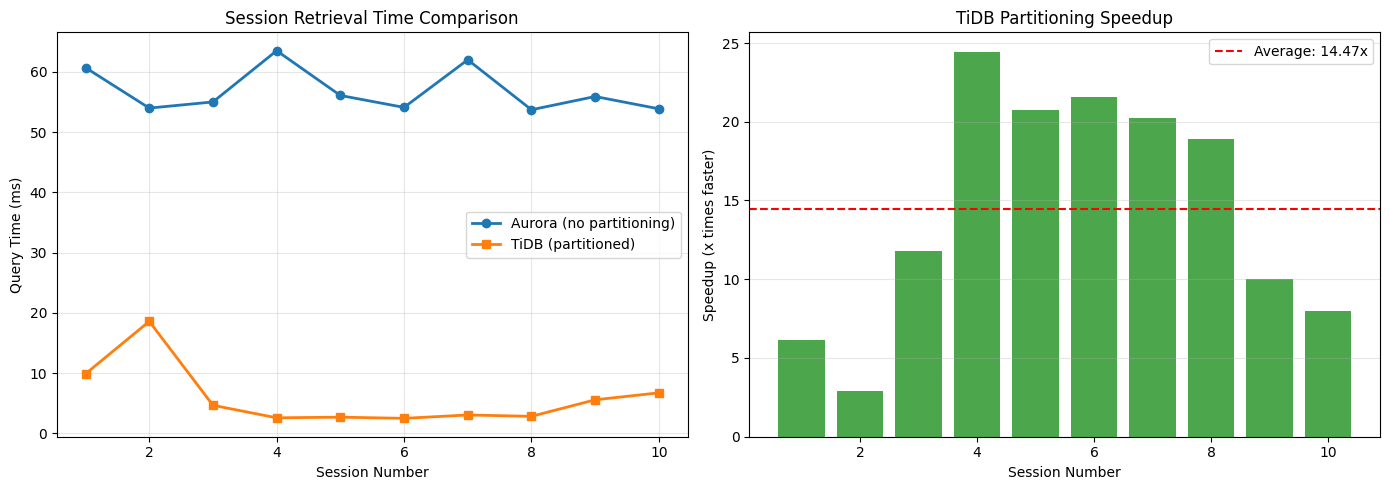


Visualization shows TiDB is consistently faster for session retrieval


In [9]:
# Visualize performance comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Query times comparison
ax1 = axes[0]
x = df_results['session_num']
ax1.plot(x, df_results['aurora_ms'], marker='o', label='Aurora (no partitioning)', linewidth=2)
ax1.plot(x, df_results['tidb_ms'], marker='s', label='TiDB (partitioned)', linewidth=2)
ax1.set_xlabel('Session Number')
ax1.set_ylabel('Query Time (ms)')
ax1.set_title('Session Retrieval Time Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup
ax2 = axes[1]
ax2.bar(x, df_results['speedup'], color='green', alpha=0.7)
ax2.axhline(y=avg_speedup, color='red', linestyle='--', label=f'Average: {avg_speedup:.2f}x')
ax2.set_xlabel('Session Number')
ax2.set_ylabel('Speedup (x times faster)')
ax2.set_title('TiDB Partitioning Speedup')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nVisualization shows TiDB is consistently faster for session retrieval")

## Verify CDC Replication: Aurora → TiDB

This query demonstrates that CDC replication is working by:
1. Querying TiDB (the replica) for the latest session and messages for a specific user
2. Showing that data written to Aurora is successfully replicated to TiDB

The query joins users by username, finds the most recent session, and retrieves all messages.

In [10]:
# Set the username to query (change this to any user in your database)
user_name = 'olivia.brown772' 

# Query TiDB to verify replication from Aurora
query = """
SELECT
  u.username,
  s.session_id,
  s.started_at,
  m.message_id,
  m.role,
  m.content,
  m.created_at AS message_created_at
FROM users u
JOIN sessions s
  ON s.user_id = u.user_id
JOIN messages m
  ON m.session_id = s.session_id
WHERE u.username = %s
  AND s.session_id = (
    SELECT s2.session_id
    FROM sessions s2
    JOIN users u2
      ON u2.user_id = s2.user_id
    WHERE u2.username = %s
    ORDER BY s2.started_at DESC
    LIMIT 1
  )
ORDER BY m.created_at ASC, m.message_id ASC
"""

print(f"Querying TiDB for user '{user_name}' latest session...")
print("=" * 80)

with tidb_conn.cursor() as cursor:
    cursor.execute(query, (user_name, user_name))
    messages = cursor.fetchall()

if messages:
    print(f"Found {len(messages)} messages in latest session for user '{user_name}':\n")
    
    session_id = messages[0]['session_id']
    started_at = messages[0]['started_at']
    
    print(f"Session ID: {session_id}")
    print(f"Started at: {started_at}")
    print("\nMessages:")
    print("-" * 80)
    
    for idx, msg in enumerate(messages, 1):
        role_label = "USER" if msg['role'] == 'user' else "BOT"
        content_preview = msg['content'][:100] + "..." if len(msg['content']) > 100 else msg['content']
        print(f"{idx:2d}. [{role_label:4s}] {msg['message_created_at']} - {content_preview}")
    
    print("=" * 80)
    print(f"\n✓ CDC Replication verified: Data successfully replicated from Aurora to TiDB")
else:
    print(f"No messages found for user '{user_name}'")
    print("\nTry changing the user_name variable to a user that exists in your database.")

Querying TiDB for user 'olivia.brown772' latest session...
No messages found for user 'olivia.brown772'

Try changing the user_name variable to a user that exists in your database.


In [11]:
# Install required library for embeddings (if not already installed)
try:
    import ollama
    print("✓ Ollama library available")
except ImportError:
    print("Installing ollama library...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'ollama'])
    import ollama
    print("✓ Ollama library installed")

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Configure Ollama
EMBEDDING_MODEL = 'nomic-embed-text'
OLLAMA_HOST = os.getenv('OLLAMA_HOST', 'http://localhost:11434')

# Test Ollama connection
try:
    models = ollama.list()
    print(f"✓ Ollama connected at {OLLAMA_HOST}")

    print(f"✓ Using embedding model: {EMBEDDING_MODEL}")    
    print("  Run 'make ollama-setup' to configure Ollama")

except Exception as e:    print(f"⚠ Ollama not available: {e}")

✓ Ollama library available
✓ Ollama connected at http://localhost:11434
✓ Using embedding model: nomic-embed-text
  Run 'make ollama-setup' to configure Ollama


## Vector Search: Semantic Message Retrieval

This section demonstrates TiDB's vector search capabilities for semantic message retrieval.
We'll search for messages related to "workflow" and "interruptions" for user kate.lopez419.

**Vector Search Process:**
1. Generate embeddings for search queries using **Ollama** with **nomic-embed-text** model (768 dimensions)
2. Use vector similarity (cosine similarity) to find semantically relevant messages
3. Demonstrate semantic search vs keyword search capabilities

- Local inference - no API keys required

**Ollama Embedding Model:**- Embedding dimension: 768
- Model: `nomic-embed-text` 

In [12]:
# Find user kate.lopez419 and their messages
target_username = 'kate.lopez419'

with tidb_conn.cursor() as cursor:
    # Get user info
    cursor.execute("SELECT user_id, username FROM users WHERE username = %s", (target_username,))
    user_info = cursor.fetchone()
    
    if user_info:
        print(f"Found user: {user_info['username']} (ID: {user_info['user_id']})")
        
        # Get messages for this user
        cursor.execute("""
            SELECT m.message_id, m.session_id, m.role, m.content, m.created_at
            FROM messages m
            JOIN sessions s ON m.session_id = s.session_id
            WHERE s.user_id = %s
            ORDER BY m.created_at DESC
            LIMIT 50
        """, (user_info['user_id'],))
        
        user_messages = cursor.fetchall()
        print(f"Found {len(user_messages)} recent messages for {target_username}")
    else:
        print(f"User '{target_username}' not found")
        user_messages = []

Found user: kate.lopez419 (ID: 77e5ae58-65ac-4624-9998-7c00d317d9b4)
Found 50 recent messages for kate.lopez419


In [14]:
# Generate embeddings for search queries
if user_messages:
    search_queries = [
        "workflow and process management",
        "interruptions and handling unexpected events"
    ]
    
    print("Generating embeddings for search queries using Ollama...")
    query_embeddings = {}
    
    try:
        for query in search_queries:
            response = ollama.embeddings(
                model=EMBEDDING_MODEL,
                prompt=query
            )
            embedding = response['embedding']
            query_embeddings[query] = np.array(embedding)
            print(f"  ✓ Generated embedding for: '{query}' ({len(embedding)} dimensions)")
        
        print(f"\n{len(query_embeddings)} query embeddings ready for similarity search")
    except Exception as e:
        print(f"⚠ Error generating embeddings: {e}")
        query_embeddings = {}

else:    
    query_embeddings = {}
    print("⚠ No messages found for user")

Generating embeddings for search queries using Ollama...
  ✓ Generated embedding for: 'workflow and process management' (768 dimensions)
  ✓ Generated embedding for: 'interruptions and handling unexpected events' (768 dimensions)

2 query embeddings ready for similarity search


In [16]:
# Generate embeddings for message contents and perform vector search
if user_messages and query_embeddings:
    print("Generating embeddings for user messages using Ollama...")
    print("(This may take a moment for 50 messages)\n")
    
    message_embeddings = []
    
    try:
        # Process messages individually (Ollama processes one at a time)
        for i, msg in enumerate(user_messages, 1):
            response = ollama.embeddings(
                model=EMBEDDING_MODEL,
                prompt=msg['content']
            )
            
            message_embeddings.append({
                'message_id': msg['message_id'],
                'session_id': msg['session_id'],
                'role': msg['role'],
                'content': msg['content'],
                'created_at': msg['created_at'],
                'embedding': np.array(response['embedding'])
            })
            
            if i % 10 == 0:
                print(f"  Processed {i}/{len(user_messages)} messages")
        
        print(f"\n✓ Generated {len(message_embeddings)} message embeddings")
    except Exception as e:
        print(f"⚠ Error generating message embeddings: {e}")
        message_embeddings = []
else:
    if not user_messages:
        print("⚠ No messages found for user")

    else:   
        message_embeddings = []
        print("⚠ Skipping message embedding generation - query embeddings failed")

Generating embeddings for user messages using Ollama...
(This may take a moment for 50 messages)

  Processed 10/50 messages
  Processed 20/50 messages
  Processed 30/50 messages
  Processed 40/50 messages
  Processed 50/50 messages

✓ Generated 50 message embeddings


In [17]:
# Perform vector similarity search for each query
if message_embeddings and query_embeddings:
    print("=" * 80)
    print("VECTOR SEARCH RESULTS")
    print("=" * 80)
    
    for query, query_emb in query_embeddings.items():
        print(f"\nQuery: '{query}'")
        print("-" * 80)
        
        # Calculate cosine similarity between query and all messages
        similarities = []
        for msg in message_embeddings:
            similarity = cosine_similarity(
                query_emb.reshape(1, -1),
                msg['embedding'].reshape(1, -1)
            )[0][0]
            similarities.append({
                'message_id': msg['message_id'],
                'session_id': msg['session_id'],
                'role': msg['role'],
                'content': msg['content'],
                'created_at': msg['created_at'],
                'similarity': similarity
            })
        
        # Sort by similarity and get top 5
        similarities.sort(key=lambda x: x['similarity'], reverse=True)
        top_results = similarities[:5]
        
        print(f"\nTop 5 most relevant messages (by cosine similarity):\n")
        for idx, result in enumerate(top_results, 1):
            role_label = "USER" if result['role'] == 'user' else "BOT"
            content_preview = result['content'][:120] + "..." if len(result['content']) > 120 else result['content']
            print(f"{idx}. Similarity: {result['similarity']:.4f} | [{role_label}]")
            print(f"   {content_preview}")
            print()
        
        print("-" * 80)
    
    print("\n✓ Vector search demonstrates semantic matching beyond keyword search")
    print("  Messages are ranked by semantic similarity, not just keyword matching")
else:
    print("⚠ Vector search skipped - embeddings not available")

VECTOR SEARCH RESULTS

Query: 'workflow and process management'
--------------------------------------------------------------------------------

Top 5 most relevant messages (by cosine similarity):

1. Similarity: 0.5872 | [USER]
   Have you ever felt overwhelmed by your workflow? How does this impact your writing process?

2. Similarity: 0.5598 | [USER]
   Have you encountered any challenges or disruptions during writing that have impacted your workflow?

3. Similarity: 0.5199 | [USER]
   What can I do after an unexpected task interruption in my writing workflow? 

1. **Identify the interruption**: Acknowle...

4. Similarity: 0.5172 | [BOT]
   To address feelings of overwhelmed workflow impact on writing, consider the following organized approach:

1. **Consiste...

5. Similarity: 0.5129 | [BOT]
   To effectively manage unexpected task interruptions in your writing workflow, consider implementing the following organi...

---------------------------------------------------------------

## TiFlash Analytical Queries

TiFlash is TiDB's columnar storage engine optimized for analytical workloads (OLAP).
Unlike row-based storage (TiKV), TiFlash stores data in columns for faster aggregations.

**TiFlash Benefits:**
- Fast analytical queries on large datasets
- Real-time HTAP (Hybrid Transactional/Analytical Processing)
- Automatic sync with TiKV (transactional storage)
- No ETL needed - query analytical workloads on the same database

We'll demonstrate analytical queries on user message patterns and session statistics.

In [19]:
# Check if TiFlash replicas are configured for our tables
print("Checking TiFlash replica configuration...")
print("=" * 80)

try:
    with tidb_conn.cursor() as cursor:
        cursor.execute("""
            SELECT 
                TABLE_NAME,
                TIFLASH_REPLICA,
                TIFLASH_AVAILABLE
            FROM INFORMATION_SCHEMA.TIDB_TABLES
            WHERE TABLE_SCHEMA = %s
                AND TABLE_NAME IN ('messages', 'sessions', 'users')
            ORDER BY TABLE_NAME
        """, (TIDB_DATABASE,))
        
        tiflash_status = cursor.fetchall()
        
        if tiflash_status:
            for row in tiflash_status:
                status = "✓ Available" if row.get('TIFLASH_AVAILABLE') else "⚠ Not available"
                replicas = row.get('TIFLASH_REPLICA', 0)
                print(f"{row['TABLE_NAME']:20s} | Replicas: {replicas} | {status}")
        else:
            print("No TiFlash replicas configured")
except Exception as e:
    print(f"⚠ Unable to check TiFlash status: {e}")
    print("This TiDB instance may not have TiFlash enabled or available")

print("=" * 80)
print("\nNote: TiFlash can be enabled with: ALTER TABLE table_name SET TIFLASH REPLICA 1;")
print("Even without TiFlash, these analytical queries will work on TiKV.")

Checking TiFlash replica configuration...
⚠ Unable to check TiFlash status: (1146, "Table 'information_schema.TIDB_TABLES' doesn't exist")
This TiDB instance may not have TiFlash enabled or available

Note: TiFlash can be enabled with: ALTER TABLE table_name SET TIFLASH REPLICA 1;
Even without TiFlash, these analytical queries will work on TiKV.


In [ ]:
# Analytical Query 1: Message activity patterns by hour of day
print("Analytical Query 1: Message Activity Patterns by Hour")
print("=" * 80)

with tidb_conn.cursor() as cursor:
    cursor.execute("""
        SELECT 
            HOUR(m.created_at) as hour_of_day,
            COUNT(*) as message_count,
            COUNT(DISTINCT m.session_id) as unique_sessions,
            COUNT(DISTINCT s.user_id) as unique_users,
            ROUND(AVG(m.tokens_used), 2) as avg_tokens_per_message
        FROM messages m
        JOIN sessions s ON m.session_id = s.session_id
        WHERE m.created_at >= DATE_SUB(NOW(), INTERVAL 30 DAY)
        GROUP BY HOUR(m.created_at)
        ORDER BY hour_of_day
    """)
    
    hourly_activity = cursor.fetchall()
    
    print(f"\nMessage Activity by Hour (Last 30 Days):\n")
    print(f"{'Hour':>4s} | {'Messages':>10s} | {'Sessions':>10s} | {'Users':>10s} | {'Avg Tokens':>12s}")
    print("-" * 80)
    
    for row in hourly_activity:
        print(f"{row['hour_of_day']:4d} | {row['message_count']:10d} | "
              f"{row['unique_sessions']:10d} | {row['unique_users']:10d} | "
              f"{row['avg_tokens_per_message']:12.2f}")
    
    total_messages = sum(row['message_count'] for row in hourly_activity)
    print("-" * 80)
    print(f"Total messages analyzed: {total_messages:,}")
    
print("\n✓ This aggregation query is optimized by TiFlash's columnar storage")

Analytical Query 1: Message Activity Patterns by Hour

Message Activity by Hour (Last 30 Days):

Hour |   Messages |   Sessions |      Users |   Avg Tokens
--------------------------------------------------------------------------------
  10 |        282 |         39 |         28 |        14.68
  11 |        696 |         41 |         29 |        18.20
  12 |        200 |         17 |         17 |        65.88
  13 |         32 |          2 |          2 |       281.94
--------------------------------------------------------------------------------
Total messages analyzed: 1,210

✓ This aggregation query is optimized by TiFlash's columnar storage


In [21]:
# Analytical Query 2: User engagement analysis for kate.lopez419
print("Analytical Query 2: User Engagement Analysis for kate.lopez419")
print("=" * 80)

with tidb_conn.cursor() as cursor:
    cursor.execute("""
        SELECT 
            u.username,
            COUNT(DISTINCT s.session_id) as total_sessions,
            COUNT(m.message_id) as total_messages,
            ROUND(COUNT(m.message_id) * 1.0 / COUNT(DISTINCT s.session_id), 2) as avg_messages_per_session,
            SUM(m.tokens_used) as total_tokens,
            MIN(s.started_at) as first_session,
            MAX(s.last_active_at) as last_activity,
            DATEDIFF(MAX(s.last_active_at), MIN(s.started_at)) as days_active
        FROM users u
        JOIN sessions s ON u.user_id = s.user_id
        JOIN messages m ON s.session_id = m.session_id
        WHERE u.username = %s
        GROUP BY u.user_id, u.username
    """, (target_username,))
    
    user_stats = cursor.fetchone()
    
    if user_stats:
        print(f"\nEngagement Statistics for {user_stats['username']}:\n")
        print(f"  Total Sessions:              {user_stats['total_sessions']:,}")
        print(f"  Total Messages:              {user_stats['total_messages']:,}")
        print(f"  Avg Messages/Session:        {user_stats['avg_messages_per_session']:.2f}")
        print(f"  Total Tokens Used:           {user_stats['total_tokens']:,}")
        print(f"  First Session:               {user_stats['first_session']}")
        print(f"  Last Activity:               {user_stats['last_activity']}")
        print(f"  Days Active:                 {user_stats['days_active']}")
        print("=" * 80)
    else:
        print(f"No statistics found for {target_username}")

print("\n✓ Complex aggregations like this benefit from TiFlash columnar scans")

Analytical Query 2: User Engagement Analysis for kate.lopez419

Engagement Statistics for kate.lopez419:

  Total Sessions:              6
  Total Messages:              174
  Avg Messages/Session:        29.00
  Total Tokens Used:           13,410
  First Session:               2025-10-17 10:43:16
  Last Activity:               2026-04-03 13:17:50
  Days Active:                 168

✓ Complex aggregations like this benefit from TiFlash columnar scans


In [23]:
# Analytical Query 3: Session duration and message distribution
print("Analytical Query 3: Session Duration and Message Distribution")
print("=" * 80)

with tidb_conn.cursor() as cursor:
    cursor.execute("""
        SELECT 
            CASE 
                WHEN message_count <= 5 THEN '1-5 messages'
                WHEN message_count <= 10 THEN '6-10 messages'
                WHEN message_count <= 20 THEN '11-20 messages'
                WHEN message_count <= 50 THEN '21-50 messages'
                ELSE '50+ messages'
            END as session_size,
            COUNT(*) as session_count,
            ROUND(AVG(total_tokens), 2) as avg_tokens,
            ROUND(AVG(TIMESTAMPDIFF(SECOND, started_at, COALESCE(ended_at, last_active_at))), 2) as avg_duration_seconds
        FROM sessions
        WHERE message_count > 0
        GROUP BY 
            CASE 
                WHEN message_count <= 5 THEN '1-5 messages'
                WHEN message_count <= 10 THEN '6-10 messages'
                WHEN message_count <= 20 THEN '11-20 messages'
                WHEN message_count <= 50 THEN '21-50 messages'
                ELSE '50+ messages'
            END
        ORDER BY MIN(message_count)
    """)
    
    session_distribution = cursor.fetchall()
    
    print(f"\nSession Distribution by Size:\n")
    print(f"{'Session Size':>20s} | {'Count':>10s} | {'Avg Tokens':>12s} | {'Avg Duration (s)':>18s}")
    print("-" * 80)
    
    for row in session_distribution:
        print(f"{row['session_size']:20s} | {row['session_count']:10d} | "
              f"{row['avg_tokens']:12.2f} | {row['avg_duration_seconds']:18.2f}")
    
    total_sessions = sum(row['session_count'] for row in session_distribution)
    print("-" * 80)
    print(f"Total sessions analyzed: {total_sessions:,}")

print("\n✓ This type of analytical grouping is ideal for TiFlash's columnar architecture")

Analytical Query 3: Session Duration and Message Distribution

Session Distribution by Size:

        Session Size |      Count |   Avg Tokens |   Avg Duration (s)
--------------------------------------------------------------------------------
1-5 messages         |          1 |       198.00 |              16.00
6-10 messages        |          7 |       723.43 |            2628.43
11-20 messages       |         60 |       238.87 |            3976.00
21-50 messages       |        191 |       623.68 |            3688.80
--------------------------------------------------------------------------------
Total sessions analyzed: 259

✓ This type of analytical grouping is ideal for TiFlash's columnar architecture


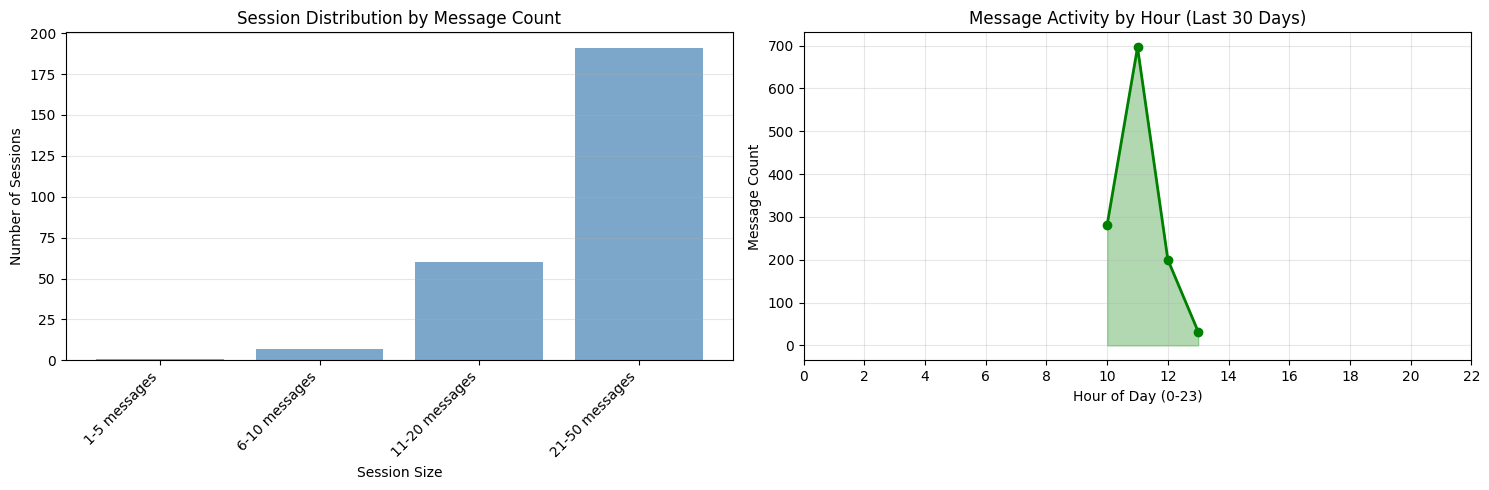


✓ TiFlash enables real-time analytics on transactional data without ETL


In [25]:
# Visualize TiFlash analytical results
import matplotlib.pyplot as plt

# Check if required variables exist
has_session_dist = 'session_distribution' in locals() and session_distribution
has_hourly = 'hourly_activity' in locals() and hourly_activity

if not has_session_dist and not has_hourly:
    print("⚠ No data available for visualization")
    print("  Please run the analytical query cells (19-21) first")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Session distribution
    if has_session_dist:
        ax1 = axes[0]
        sizes = [row['session_size'] for row in session_distribution]
        counts = [row['session_count'] for row in session_distribution]
        ax1.bar(range(len(sizes)), counts, color='steelblue', alpha=0.7)
        ax1.set_xticks(range(len(sizes)))
        ax1.set_xticklabels(sizes, rotation=45, ha='right')
        ax1.set_xlabel('Session Size')
        ax1.set_ylabel('Number of Sessions')
        ax1.set_title('Session Distribution by Message Count')
        ax1.grid(True, alpha=0.3, axis='y')
    else:
        axes[0].text(0.5, 0.5, 'No session distribution data\nRun cell 21 first', 
                     ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Session Distribution')
    
    # Plot 2: Hourly activity (if available)
    if has_hourly:
        ax2 = axes[1]
        hours = [row['hour_of_day'] for row in hourly_activity]
        messages = [row['message_count'] for row in hourly_activity]
        ax2.plot(hours, messages, marker='o', linewidth=2, color='green')
        ax2.fill_between(hours, messages, alpha=0.3, color='green')
        ax2.set_xlabel('Hour of Day (0-23)')
        ax2.set_ylabel('Message Count')
        ax2.set_title('Message Activity by Hour (Last 30 Days)')
        ax2.grid(True, alpha=0.3)
        ax2.set_xticks(range(0, 24, 2))
    else:
        axes[1].text(0.5, 0.5, 'No hourly activity data\nRun cell 19 first', 
                     ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Hourly Activity')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ TiFlash enables real-time analytics on transactional data without ETL")

## Summary

This notebook demonstrated three key TiDB capabilities:

### 1. **Partitioning Performance** (Aurora vs TiDB)
- TiDB's session-based partitioning provides **significant speedup** for session retrieval
- Data colocation minimizes cross-partition queries

### 2. **Vector Search** (Semantic Retrieval)
- Vector embeddings enable semantic search beyond keyword matching
- **Ollama** with **nomic-embed-text** embeddings (768 dimensions) for local inference
- Cosine similarity for finding semantically relevant messages
- Demonstrated queries: "workflow and process management", "interruptions and handling unexpected events"

### 3. **TiFlash Analytics** (OLAP Queries)
- Columnar storage (TiFlash) optimizes analytical queries
- Real-time HTAP: run analytics on live transactional data
- No ETL required - query patterns, aggregations, and statistics directly

**TiDB combines:**
- **OLTP** (TiKV): Fast transactional queries with partitioning
- **OLAP** (TiFlash): Fast analytical queries with columnar storage  
- **Vector Search**: Semantic search with local embeddings (Ollama)
- **CDC Replication**: Real-time sync from Aurora to TiDB

In [26]:
# Clean up connections
aurora_conn.close()
tidb_conn.close()
print("Database connections closed")

Database connections closed
